In [ ]:
import config_paths_ipynb

import numpy as np
import matplotlib.pyplot as plt
import glycowork.glycan_data.stats as glwstats

from sklearn.preprocessing import FunctionTransformer

from ibd_biom_glycoda.config import DATASETS_DIR
from ibd_biom_glycoda.utils import seed_everything
from ibd_biom_glycoda.data.dataset import load_dataset_excel, prepare_ibd_dataset
from ibd_biom_glycoda.data.transformations import CLRProcessor, GlyCompareProcessor
from ibd_biom_glycoda.analysis.pipelines import make_preprocessors
from ibd_biom_glycoda.analysis.loco_cv import run_loco_cv, aggregate_loco_results_per_test_cohort, summarize_loco_results_all
from ibd_biom_glycoda.evaluation.domain_generalization import plot_between_test_cohort_metrics_overall
from ibd_biom_glycoda.evaluation.subgroup_analysis import plot_between_test_cohort_metrics_subgroup
from ibd_biom_glycoda.plotting.style import rcparams_aga, create_figure_with_panels, generate_semantic_colors

# Seed everything
SEED = 42
seed_everything(SEED)
# Override glycowork RNG
glwstats.rng = np.random.default_rng(SEED)

# Load and preprocess data
fname = 'ibd_biom_prospective_dataset_baseline.xlsx'
df_ibd = load_dataset_excel(fname, data_dir=DATASETS_DIR)

# Specify dataset
BINARY = True
FULL_STRATIFICATION = False
SAMPLE_WEIGHTS = True
INCLUDE_COVARIATES = True

df_full, _ = prepare_ibd_dataset(df_ibd, binary=BINARY)
df_binary, coda_cols = prepare_ibd_dataset(df_ibd, binary=BINARY, controls=['CD'], cases=['UC'])

print(f"\nNumber of samples in the full dataset: {len(df_full)}")
print(f"Number of samples in the binary dataset (CD vs UC): {len(df_binary)}")
print(f"Number of CODA features: {len(coda_cols)}")
print(f"Disease distribution:\n{df_binary['DISEASE'].value_counts()}")
# Define test cohorts
LOCO_TEST_COHORTS = ['UK', 'US', 'IT', 'NL']

# Specify the number of randomization runs
seeds = [0, 17, 42, 1000, 1997, 2025, 10000, 20250, 50000, 99999]
num_runs = 5  # You can set this from 1 to len(seeds)
selected_seeds = seeds[:num_runs]

# Specify the number of folds for inner cross-validation
K = 5

# Specify model hyperparameters
# No class_weight: SAMPLE_WEIGHTS already balances classes, and applying both would double-correct.
PARAMETERS_LR = {
    'C': 0.1,
    'penalty': 'l2',
    'solver': 'saga',
    'max_iter': 1000,
}

PARAMETERS_XB = {
    'n_estimators': 50,
    'learning_rate': 0.05,
    'max_depth': 2,
    'objective': 'multi:softprob' if not BINARY else 'binary:logistic',
    'eval_metric': 'mlogloss' if not BINARY else 'logloss',
    'early_stopping_rounds': 5,
}

PARAMETERS_ALL = {
    'LR': PARAMETERS_LR,
    'XB': PARAMETERS_XB,
}

PALETTE = 'okabe_ito'
rcparams_aga(palette=PALETTE)
DISEASE_COLORS, COHORT_COLORS, METRICS_COLORS, SUBGROUP_COLORS, PROCESSOR_COLORS, MODEL_COLORS = generate_semantic_colors(palette=PALETTE, preview=False)

In [ ]:
# Define estimators
MODEL_KEYS = ['LR']

# Define preprocessors
processors = {
    'Raw': FunctionTransformer(lambda X: X.values if hasattr(X, "values") else X, validate=False),
    'CLR': CLRProcessor(gamma=0.1, seed=seeds[0]),
    'GlyCmp': GlyCompareProcessor(orig_df=df_full, coda_cols=coda_cols, abd_fname='glycomotif_abd_df.xlsx', annot_fname='glycomotif_annot_df.xlsx', data_dir=DATASETS_DIR),

}
PROCESSOR_KEYS = ['Raw', 'CLR', 'GlyCmp']
scaled_procs = make_preprocessors(processors, PROCESSOR_KEYS, with_scaler=True)

# Print problem definition
PIPELINE_KEYS = [ f"{m}+{p}" for p in PROCESSOR_KEYS for m in MODEL_KEYS ]
print(f"Pipeline keys: {PIPELINE_KEYS}")
print(f"Number of pipeline keys: {len(PIPELINE_KEYS)}")
print(f"LOCO Inner CV with K={K} folds - LOCO repeated over {num_runs} runs")

In [ ]:
# Run LOCO CV
all_results = run_loco_cv(
    df=df_binary,
    feature_cols=coda_cols,
    loco_test_cohorts=LOCO_TEST_COHORTS,
    selected_seeds=selected_seeds,
    scaled_procs=scaled_procs,
    model_keys=MODEL_KEYS,
    model_parameters=PARAMETERS_ALL,
    pipeline_keys=PIPELINE_KEYS,
    n_folds=K,
    use_full_stratification_inner_cv=FULL_STRATIFICATION,
    use_sample_weights=SAMPLE_WEIGHTS,
    include_covariates=INCLUDE_COVARIATES,
    val_size_inner=0.01, # small validation set since hyperparameters are fixed
    n_jobs=10
)

results_loco_raw, results_loco_raw_labels = all_results['raw'], all_results['labels']

In [4]:
# Analyze and print results for each test cohort
VARS = ['disease', 'age_sex']
METRICS = ['AUROC', 'LogLoss', 'Sensitivity', 'Specificity']
SETS = ['train', 'val_in', 'test_in', 'test_out']

results_loco_test_cohorts, subgroup_analyses_loco_test_cohorts = aggregate_loco_results_per_test_cohort(results_loco_raw=results_loco_raw,
                                                                                                        loco_test_cohorts=LOCO_TEST_COHORTS,
                                                                                                        pipeline_keys=PIPELINE_KEYS,
                                                                                                        vars=VARS,
                                                                                                        metrics=METRICS,
                                                                                                        sets=SETS)

Results for Test Cohort: UK
Results for Test Cohort: US
Results for Test Cohort: IT
Results for Test Cohort: NL


In [5]:
# Summarize across all cohorts with heterogeneity diagnostics
summary_all = summarize_loco_results_all(
    results_loco_test_cohorts,
    subgroup_analyses_loco=subgroup_analyses_loco_test_cohorts,
    test_cohorts=LOCO_TEST_COHORTS,
    sets=['test_in', 'test_out'],
    metrics=['AUROC', 'LogLoss', 'Sensitivity', 'Specificity'],
)

In [6]:
# Overall --> Sanity check
summary_all['disease']['test_out'].to_clipboard()

# Overall analysis

### Out-of-sample performance

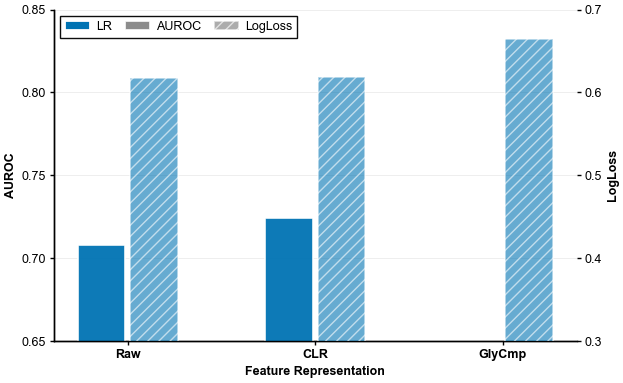

In [7]:
# Plot between-test-cohort metrics for out-of-cohort test set
AXIS_CONFIG_OVERALL = {
    "AUROC": {"primary": {"ylim": (0.65, 0.85), "yticks": np.linspace(0.65, 0.85, 5)}},
    "LogLoss": {"secondary": {"ylim": (0.30, 0.70), "yticks": np.linspace(0.30, 0.70, 5)}},
}

fig, ax1, ax2 = plot_between_test_cohort_metrics_overall(summary_all, 
                                                        model_names=(MODEL_KEYS[0]),
                                                        preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]], 
                                                        set_name='test_out', show_sem=False,
                                                        figsize=(6.5, 4),
                                                        metrics=list(AXIS_CONFIG_OVERALL.keys()),
                                                        axis_config=AXIS_CONFIG_OVERALL)
plt.tight_layout()
plt.subplots_adjust(right=0.90)  # Make room for the legend

# Subgroup analysis

### Out-of-sample performance

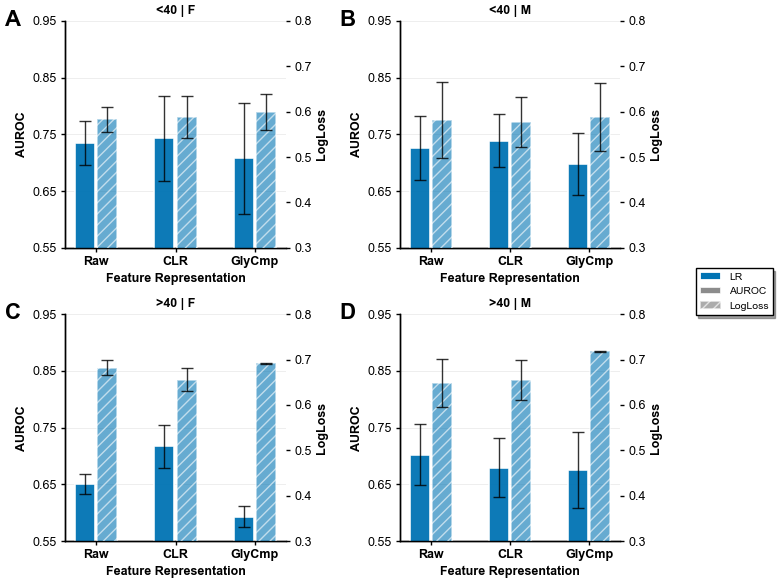

In [8]:
# Subgroup performance summary
AXIS_CONFIG_SUBGROUP = {
    "AUROC": {"primary": {"ylim": (0.55, 0.95), "yticks": np.linspace(0.55, 0.95, 5)}},
    "LogLoss": {"secondary": {"ylim": (0.30, 0.80), "yticks": np.linspace(0.30, 0.80, 6)}},
}

METRICS = list(AXIS_CONFIG_SUBGROUP.keys())

fig, axes = create_figure_with_panels(figsize=(7, 6), layout=(2, 2))

plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0]),
                                           preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]],
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['<40 | F'],
                                           show_sem=True, 
                                           ax=axes[0],
                                            axis_config=AXIS_CONFIG_SUBGROUP)
plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0]),
                                           preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]], 
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['<40 | M'], 
                                           show_sem=True, 
                                           ax=axes[1],
                                            axis_config=AXIS_CONFIG_SUBGROUP)
plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0]),
                                            preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]],
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['>40 | F'], 
                                           show_sem=True, 
                                           ax=axes[2],
                                            axis_config=AXIS_CONFIG_SUBGROUP)
plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0]),
                                            preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]],
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['>40 | M'], 
                                           show_sem=True, 
                                           ax=axes[3],
                                            axis_config=AXIS_CONFIG_SUBGROUP)

# Get legend info
legend = axes[0].get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]

# Remove both legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].get_legend().remove()
axes[3].get_legend().remove()

# Create single-column vertical legend on the side
fig.legend(handles, labels,
          loc='center left',
          bbox_to_anchor=(1.0, 0.5),
          frameon=True,
          shadow=True,
          fontsize='small',
          ncol=1)  # Single column for vertical layout

plt.tight_layout()
plt.subplots_adjust(right=0.90)  # Make room for the legend